# 🚀 Classificação de Imagens com MobileNetV3

Este notebook utiliza o modelo `mobilenetv3_small_100` da biblioteca `timm` para classificar as imagens contidas na pasta `../imagens`.

In [1]:
# Install dependencies
%pip install timm torch torchvision pillow requests matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 🛠️ Configuração e Carregamento do Modelo

Vamos carregar o modelo MobileNetV3 e as etiquetas do ImageNet.

In [2]:
import timm
import torch
from torchvision import transforms
from PIL import Image
import requests
import os
import matplotlib.pyplot as plt

# Configurações
MODEL_NAME = 'timm/mobilenetv3_small_100.lamb_in1k'
IMAGES_DIR = r'C:\Users\ivanu\Desktop\recog_system\imagens'

# Carregar o modelo
model = timm.create_model(MODEL_NAME, pretrained=True)
model.eval()

# Transformações para as imagens
data_config = timm.data.resolve_model_data_config(model)
transform = timm.data.create_transform(**data_config, is_training=False)

# Buscar os nomes das classes do ImageNet
LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
labels = requests.get(LABELS_URL).text.splitlines()

print(f"Modelo {MODEL_NAME} carregado e pronto!")

c:\Users\ivanu\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modelo timm/mobilenetv3_small_100.lamb_in1k carregado e pronto!


## 🖼️ Processamento e Visualização

Processando todas as imagens da pasta e exibindo suas classes previstas.

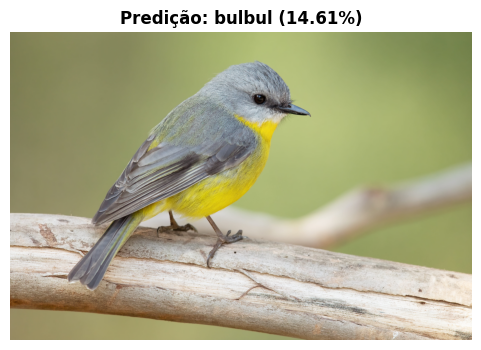

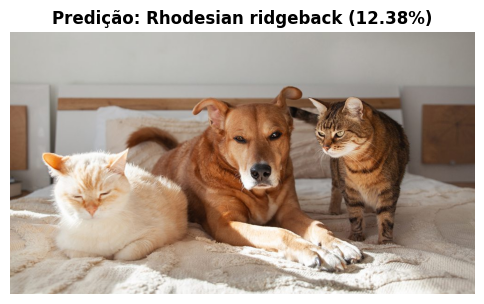

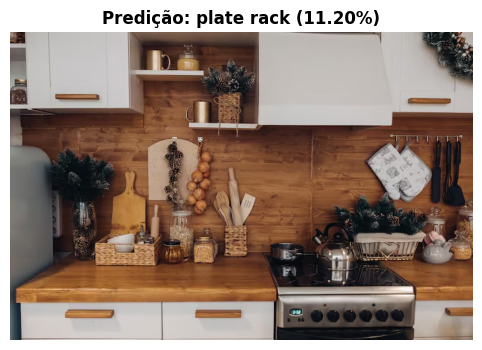

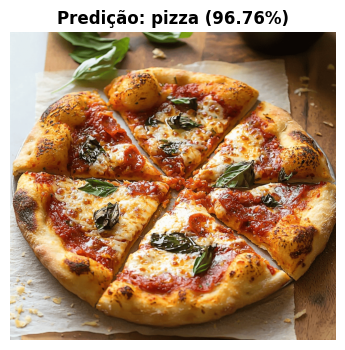

In [3]:
valid_exts = (".png", ".jpg", ".jpeg")
image_files = [f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(valid_exts)]

for img_name in image_files:
    img_path = os.path.join(IMAGES_DIR, img_name)
    img = Image.open(img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0)

    with torch.no_grad():
        output = model(input_tensor)
        
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    top_prob, top_catid = torch.topk(probabilities, 1)
    
    label = labels[top_catid]
    confidence = top_prob.item() * 100
    
    plt.figure(figsize=(6, 4))
    plt.imshow(img)
    plt.title(f"Predição: {label} ({confidence:.2f}%)", fontweight='bold')
    plt.axis('off')
    plt.show()